<a href="https://colab.research.google.com/github/sandramilosevic/license-plate-detection-yolo-ocr/blob/main/plate-recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Instalacija potrebnih paketa

In [ ]:
!pip uninstall -y kaggle kagglesdk
!pip install kaggle
!pip install ultralytics
!pip install fast-plate-ocr[onnx]

Found existing installation: kaggle 1.7.4.5
Uninstalling kaggle-1.7.4.5:
  Successfully uninstalled kaggle-1.7.4.5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 75.3 MB/s eta 0:00:00


#Učitavanje biblioteka

In [ ]:
from ultralytics import YOLO
from fast_plate_ocr import LicensePlateRecognizer
from sklearn.model_selection import train_test_split
import os
from google.colab import drive
import shutil
import yaml
from google.colab import userdata
import random
import cv2
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Definisanje putanja i pristup Drive-u

In [ ]:
drive.mount('/content/drive') # Pristup drive-u (gde je sacuvan best.pt model)
train_name = 'detekcija' # naziv direktorijuma za cuvanje trening rezultata
drive_path = f'/content/drive/MyDrive/yolo_models/{train_name}' # gde se cuva
dataset_name = 'fareselmenshawii/license-plate-dataset'
download_path = '/content/license_plate_dataset' # lokacija preuzetog dataseta
yaml_path = f'{download_path}/data.yaml'

Mounted at /content/drive


# Preuzimanje dataset-a

In [ ]:
def downloading_ds():
  os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
  os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

  import kaggle

  kaggle.api.authenticate()

  if not os.path.exists(download_path):
    os.makedirs(download_path)

  kaggle.api.dataset_download_files(
      dataset=dataset_name,
      path=download_path,
      unzip=True
  )

  return download_path

In [ ]:
folder_path = downloading_ds()

Dataset URL: https://www.kaggle.com/datasets/fareselmenshawii/license-plate-dataset


# Kreiranje test foldera

In [ ]:
def test_data(folder_path):
  # Podela val foldera, sa ciljem da se dobije test skup podataka
  validacija_slike = os.path.join(folder_path, 'images', 'val')
  validacija_label = os.path.join(folder_path, 'labels', 'val')

  test_slike_path = os.path.join(folder_path, 'images', 'test')
  test_label_path = os.path.join(folder_path, 'labels', 'test')

  os.makedirs(test_slike_path, exist_ok=True) # kreiranje test foldera
  os.makedirs(test_label_path, exist_ok=True)

  if len(os.listdir(test_slike_path)) > 0:
    print('Test skup već postoji, preskačemo...') # PROMENI
    return len(os.listdir(validacija_slike)), len(os.listdir(test_slike_path))
  sve_slike = os.listdir(validacija_slike)

  val_slike, test_slike = train_test_split(sve_slike, test_size = 0.5, random_state=42) # podela na pola, tako da dobijemo po ~10% podataka za test/val

  for slika in test_slike:
    # Premestamo slike u test folder
    src_slike = os.path.join(validacija_slike, slika)
    destinacija = os.path.join(test_slike_path, slika)
    shutil.move(src_slike, destinacija)

    # Uzima tekst pre poslednje tacke i dodaje 'txt' ekstenziju
    label_naziv = os.path.splitext(slika)[0] + '.txt'

    src_label = os.path.join(validacija_label, label_naziv) # pronalazi label u val folderu
    destinacija_labela = os.path.join(test_label_path, label_naziv)

    if os.path.exists(src_label):
      shutil.move(src_label, destinacija_labela)
    else:
      print('NE POSTOJI') # GRESKu prijavi

  return len(val_slike), len(test_slike)

In [ ]:
len_val, len_test = test_data(folder_path)

# Konfiguracija YAML fajla potrebnog za YOLO model

In [ ]:
# Definisanje strukture foldera u YAML format
def kreiranje_yaml(folder_path):
  dataset_yaml = {
      'path': folder_path,
      'train': 'images/train',
      'val': 'images/val',
      'test': 'images/test',
      'nc': 1,
      'names': ['license']
  }
  yaml_path = f'{folder_path}/data.yaml' # mesto cuvanja kreiranog fajla
  # Cuvanje YAML fajla
  with open(yaml_path, 'w') as f:
      yaml.dump(dataset_yaml, f)

  return yaml_path

In [ ]:
yaml_path = kreiranje_yaml(folder_path)

# Analiza sadržaja dataseta

In [ ]:
def analiza_dataseta(folder_path):
  print('Sadržaj foldera: ')
  print('-'*30)

  for folder in os.listdir(folder_path):
    print(folder)

  print('\nPodfolderi: ')
  print('-'*30)

  slike = os.path.join(folder_path, 'images')

  for i in os.listdir(slike): # Podfolderi (u images)
    print(i)

  train_data = os.path.join(slike, 'train')
  print('\nZa trening: ')
  kolicina_train = os.listdir(train_data)
  print('-'*30)
  print(len(kolicina_train))

  val_data = os.path.join(slike, 'val')
  print('\nZa validaciju: ')
  print('-'*30)
  print(len_val)

  test_data = os.path.join(slike, 'test')
  print('\nZa testiranje modela: ')
  print('-'*30)
  print(len_test)

  # Prikaz naziva slike
  naziv_slika = os.listdir(train_data)[0]
  print('\nPrimer naziva slika: ')
  print('-'*30)
  print(naziv_slika)

  label_naziv = os.path.splitext(naziv_slika)[0] + '.txt'
  label_path = os.path.join(folder_path, 'labels', 'train')

  print('\nPrimer naziva labela: ')
  print('-'*30)
  print(label_naziv)

  label_fajl = os.path.join(label_path, label_naziv)

  with open(label_fajl, 'r') as f:
    print('\nSadrzaj labela: ')
    print('-'*30)
    print(f.read())

In [ ]:
analiza = analiza_dataseta(folder_path)

Sadržaj foldera: 
------------------------------
labels
images
data.yaml

Podfolderi: 
------------------------------
val
test
train

Za trening: 
------------------------------
4295

Za validaciju: 
------------------------------
536

Za testiranje modela: 
------------------------------
537

Primer naziva slika: 
------------------------------
4fe2eddb7c280885.jpg

Primer naziva labela: 
------------------------------
4fe2eddb7c280885.txt

Sadrzaj labela: 
------------------------------
0 0.50234375 0.6688895979112272 0.68 0.44732500000000003



# Učitavanje i treniranje modela

In [ ]:
model = YOLO('yolov8s.pt')

def trening():
  model_train = model.train(
      data=yaml_path,
      epochs=100,
      batch=20,
      patience=15,
      lr0=0.001,
      lrf=0.01,
      imgsz=640,
      exist_ok=True,
      optimizer='AdamW',
      name=train_name,
      warmup_epochs=3,
      cache='disk',
      # Augmentacija
      erasing=0, # default je 40%
      degrees=5
      )

  shutil.copytree(
      f'/content/runs/detect/{train_name}',
      drive_path,
      dirs_exist_ok=True
  )
  return model_train

In [ ]:
# rezultat = trening()

'''
Preskacemo ponovno treniranje, koristimo trenirani model

'''

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=20, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/license_plate_dataset/data.yaml, degrees=5, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=detekcija, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=15, 

'\nPreskacemo ponovno treniranje, koristimo trenirani model\n\n'

# Perfomanse modela

In [ ]:
graf =  f'{drive_path}/results.png'
conf_matrix = f'{drive_path}/confusion_matrix.png'
pred_path = f'{drive_path}/val_batch1_pred.jpg'

naslovi = ['Metrike uspesnosti',
           'Analiza gresaka (matrica konfuzije)',
           'Detekcija tablica u realnim uslovima']

def prikaz_slike(slika_path, naslov):
  img = cv2.imread(slika_path)
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  plt.figure(figsize=(12, 6))
  plt.imshow(img)
  plt.axis('off')
  plt.title(naslov, pad=16)
  plt.show()


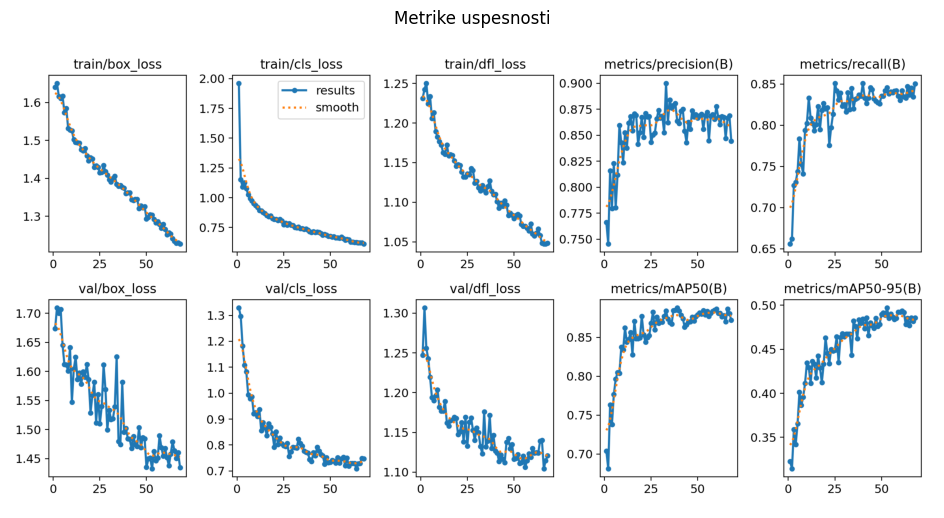

In [ ]:
prikaz_slike(graf, naslovi[0])

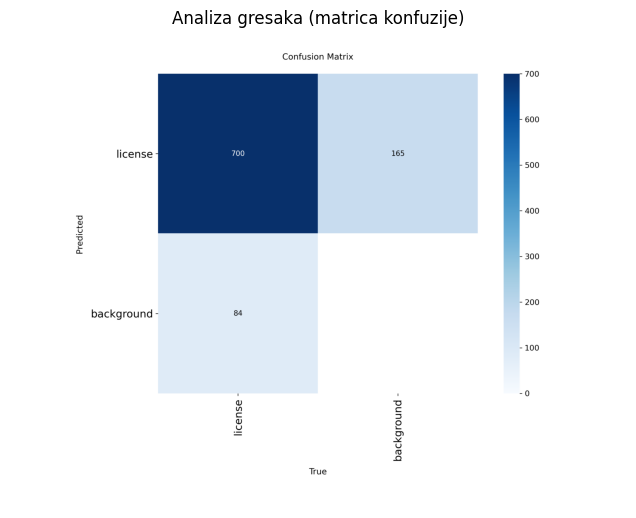

In [ ]:
prikaz_slike(conf_matrix, naslovi[1])

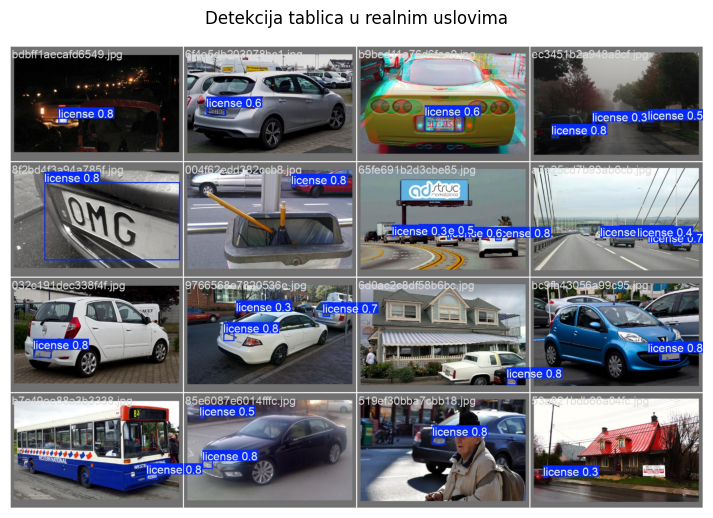

In [ ]:
prikaz_slike(pred_path, naslovi[2])

# Učitavanje best.pt modela sa Drive-a

In [ ]:
best_model_path = f'{drive_path}/weights/best.pt'
best_model = YOLO(best_model_path)

# Validacija (najboljeg) modela na test skupu podataka


In [ ]:
testiranje = best_model.val(data=yaml_path, split='test')

print(f"mAP50: {testiranje.box.map50:.1%}")
print(f"mAP50-95: {testiranje.box.map:.1%}")
print(f"Preciznost: {testiranje.box.mp:.1%}")
print(f"Koliko % tablica pronalazi: {testiranje.box.mr:.1%}")

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1998.8±823.3 MB/s, size: 307.5 KB)
val: Scanning /content/license_plate_dataset/labels/test.cache... 537 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 537/537 160.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 34/34 9.7s/it 5:31
                   all        537        809       0.87      0.816      0.868      0.466
Speed: 5.1ms preprocess, 597.7ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /content/runs/detect/val5
mAP50: 86.8%
mAP50-95: 46.6%
Preciznost: 87.0%
Koliko % tablica pronalazi: 81.6%


In [ ]:
reader = LicensePlateRecognizer('global-plates-mobile-vit-v2-model')


image 1/1 /content/license_plate_dataset/images/test/bb7725fec4fc0967.jpg: 480x640 3 licenses, 446.7ms
Speed: 3.9ms preprocess, 446.7ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)


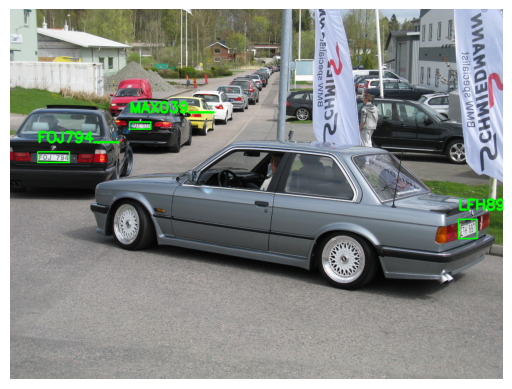

Broj detektovanih tablica: 3

image 1/1 /content/license_plate_dataset/images/test/bb7725fec4fc0967.jpg: 480x640 3 licenses, 448.2ms
Speed: 4.8ms preprocess, 448.2ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)
['MAX039___']


In [ ]:
test_folder = os.path.join(folder_path, 'images', 'test')
random_slika = os.path.join(test_folder, random.choice(os.listdir(test_folder)))
def predikcija_bboxa(random_slika, model):
    predikcija = model(random_slika)[0]
    slika = cv2.imread(random_slika)

    for box in predikcija.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        isecak = slika[y1:y2, x1:x2]

        isecak_gray = cv2.cvtColor(isecak, cv2.COLOR_BGR2GRAY)
        rezultat_ocr = reader.run(isecak_gray)
        tekst = rezultat_ocr[0]
        tekst_y = y1 - 20 if y1 - 20 > 20 else y2 + 30  # ako nema mesta gore, ispiši ispod

        cv2.rectangle(slika, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(slika, tekst, (x1, tekst_y), fontFace=cv2.FONT_HERSHEY_SIMPLEX,
                    fontScale=1, color=(0, 255, 0), thickness=3)

    slika_rgb = cv2.cvtColor(slika, cv2.COLOR_BGR2RGB)
    plt.imshow(slika_rgb)
    plt.axis('off')
    plt.show()
    print(f"Broj detektovanih tablica: {len(predikcija.boxes)}")
    predikcija = model(random_slika, conf=0.5)[0]
    print(rezultat_ocr)

predikcija_bboxa(random_slika, best_model)